# Code to make figures regarding the parameter scan
Merge all the inference files into one csv file with correlations + parameter information

In [4]:
import pandas as pd
from pathlib import Path

In [ ]:
parameter_df_activation = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/parameters_3genes_positive_reg_pi_on_r_add_scaled.csv", index_col=0)
parameter_df_repression = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/parameters_3genes_repression_reg_pi_on_r_add_scaled.csv", index_col=0)
output_folder = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/"
# Path to main folder
names = ["A_to_B", "A_B", "A_rep_B", "A_and_B"]
for name in names:
    path_to_main_folder = Path(f"/home/gzu5140/Keerthana_b1042/grnInference/analysisData/parameter_scan_random_null_1_20/{name}")

    # Find all CSV files inside subfolders (recursive search)
    csv_files = list(path_to_main_folder.rglob("*.csv"))

    print(f"Found {len(csv_files)} CSV files")

    # Read and concat
    df_list = [pd.read_csv(f) for f in csv_files]
    combined_df = pd.concat(df_list, ignore_index=True)
    if "rep" in name:
        parameter_df = parameter_df_repression
    else:
        parameter_df = parameter_df_activation
    parameter_df_filtered = parameter_df[parameter_df['gene_id'] != 3]
    # Function to generate param_index directly from pair_id
    def make_param_index(pid):
        start = pid * 3
        return f"{start}_{start+1}"

    parameter_df_filtered["param_index"] = parameter_df_filtered["pair_id"].apply(make_param_index)
    def clean_param_index(val):
        parts = str(val).split("_")
        if len(parts) == 3:
            return "_".join(parts[:2])
        return val  # keep as is if already 2 parts (or unexpected format)


    combined_df['param_index'] = combined_df['param_index'].apply(clean_param_index)
    combined_df_param = pd.merge(combined_df.reset_index(drop = True), parameter_df_filtered.reset_index(drop=True), on="param_index")
    combined_df_param.to_csv(f"{output_folder}/{name}_inference_results_random_scrambled.csv")

Multiple states

In [2]:
import pandas as pd
from pathlib import Path

# === PATHS ===
base_path = Path("/home/gzu5140/Keerthana_b1042/grnInference")
param_path = base_path / "simulation_data/parameter_scan_simulations/simulation_details"
analysis_path = base_path / "analysisData/parameter_scan_1_20"
output_folder = base_path / "plot_data/parameter_scan"
output_folder.mkdir(parents=True, exist_ok=True)

# === LOAD PARAMETER TABLES ===
param_act = pd.read_csv(param_path / "parameters_3genes_positive_reg_pi_on_r_add_scaled.csv", index_col=0)
param_rep = pd.read_csv(param_path / "parameters_3genes_repression_reg_pi_on_r_add_scaled.csv", index_col=0)

# --- Keep only genes 1 & 2 ---
param_act = param_act[param_act["gene_id"] != 3].copy()
param_rep = param_rep[param_rep["gene_id"] != 3].copy()

# === HELPER: ensure param_index column ===
def ensure_param_index(df):
    if "param_index" not in df.columns and "pair_id" in df.columns:
        df["param_index"] = df["pair_id"].apply(lambda pid: f"{int(pid)*3}_{int(pid)*3+1}")
    return df

param_act = ensure_param_index(param_act)
param_rep = ensure_param_index(param_rep)

# === HELPER: split param_index into state1/state2 ===
def split_param_index(series):
    parts = series.astype(str).str.split("__", expand=True)
    parts.columns = ["param_index_state1", "param_index_state2"]
    return parts.applymap(lambda x: "_".join(str(x).split("_")[:2]) if pd.notna(x) else None)

# === PROCESS EACH DATASET ===
for name in ["A_to_B_2_states", "A_B_2_states", "A_and_B_2_states", "A_rep_B_2_states"]:
    files = list((analysis_path / name).rglob("*.csv"))
    print(f"Found {len(files)} CSVs for {name}")
    if not files:
        continue

    df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
    df = pd.concat([df, split_param_index(df["param_index"])], axis=1)

    params = param_rep if "rep" in name else param_act

    # --- Merge parameters for both states ---
    for state in ["state1", "state2"]:
        merged_cols = {c: f"{c}_{state}" for c in params.columns if c != "param_index"}
        df = df.merge(params.rename(columns=merged_cols),
                      how="left", left_on=f"param_index_{state}", right_on="param_index").drop(columns="param_index", errors="ignore")

    out_path = output_folder / f"{name}_inference_results_random_scrambled.csv"
    df.to_csv(out_path, index=False)
    print(f"✅ Saved: {out_path}")

print("\nAll merges complete.")


Found 52 CSVs for A_to_B_2_states


/tmp/ipykernel_2343110/2158166909.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return parts.applymap(lambda x: "_".join(str(x).split("_")[:2]) if pd.notna(x) else None)


✅ Saved: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_to_B_2_states_inference_results_random_scrambled.csv
Found 52 CSVs for A_B_2_states


/tmp/ipykernel_2343110/2158166909.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return parts.applymap(lambda x: "_".join(str(x).split("_")[:2]) if pd.notna(x) else None)


✅ Saved: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_B_2_states_inference_results_random_scrambled.csv
Found 52 CSVs for A_and_B_2_states


/tmp/ipykernel_2343110/2158166909.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return parts.applymap(lambda x: "_".join(str(x).split("_")[:2]) if pd.notna(x) else None)


✅ Saved: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_and_B_2_states_inference_results_random_scrambled.csv
Found 52 CSVs for A_rep_B_2_states


/tmp/ipykernel_2343110/2158166909.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return parts.applymap(lambda x: "_".join(str(x).split("_")[:2]) if pd.notna(x) else None)


✅ Saved: /home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_rep_B_2_states_inference_results_random_scrambled.csv

All merges complete.


## AUROC for the gene correlation

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import os

In [5]:
folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/")
output_folder_plot = Path("/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/")
os.makedirs(output_folder_plot, exist_ok = True)


In [6]:
# === ROC helper ===
def compute_roc(tp_frac, fp_frac):
    fpr = np.clip(fp_frac, 0, 1)
    tpr = np.clip(tp_frac, 0, 1)
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
    if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
    auroc = np.trapz(tpr, fpr)
    return fpr, tpr, auroc

p_vals = np.logspace(-4, 0, 60)
z_thresholds = np.arange(0, 51, 1) 
p_fixed = 0.01
pval_col   = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20"
zscore_col = "zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1"
name_map = {
    "A_B": "X Y",
    "A_B_2_states": "X Y (multi-state)",
    "A_to_B": r"$X \rightarrow Y$",
    "A_to_B_2_states": r"$X \rightarrow Y$  (multi-state)",
    "A_and_B": r"$X \leftrightarrow Y$",
    "A_and_B_2_states": r"$X \leftrightarrow Y$ (multi-state)",
    "A_rep_B": r"$X \dashv Y$",
    "A_rep_B_2_states": r"$X \dashv Y$ (multi-state)"
}
# === Generate ROC: PART 1 – Regulation detection (All vs A_B)
dfs = {}
for csv_file in sorted(folder.glob("*_inference_results_random_scrambled.csv")):
    name = csv_file.stem.replace("_inference_results_random_scrambled", "")
    df = pd.read_csv(csv_file)
    if pval_col in df.columns and zscore_col in df.columns:
        dfs[name] = df

# === COMPUTE FRACTIONS ===
frac_curves_p = {}
frac_curves_z = {}

for name, df in dfs.items():
    if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
        df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
    elif "param_index" in df.columns:
        df["_pair_key"] = df["param_index"].astype(str)
    else:
        continue

    # --- For p-value mode (single-state vs XY)
    pair_min_p = df.groupby("_pair_key")[pval_col].min()
    frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])

    # --- For z-score mode (multi-state vs single-state)
    df_sig = df[df[pval_col] < p_fixed]
    
    if df_sig.empty:
        continue
    pair_max_z = df_sig.groupby("_pair_key")[zscore_col].max().abs()
    frac_curves_z[name] = np.array([(pair_max_z > z).mean() for z in z_thresholds])
    
results_all_vs_A_B = []
for tp_name in ["A_to_B", "A_and_B", "A_rep_B", "A_B_2_states", "A_to_B_2_states", "A_and_B_2_states", "A_rep_B_2_states"]:
    fp_name = "A_B"
    if tp_name not in frac_curves_p or fp_name not in frac_curves_p:
        print(f"⚠️ Missing {tp_name} or {fp_name} for regulation ROC")
        continue
    tp_frac = frac_curves_p[tp_name]
    fp_frac = frac_curves_p[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_all_vs_A_B.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Regulation] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")

# === Generate ROC: PART 2 – Multi-state only (2_states vs corresponding single)
results_multi_only = []
for tp_name, fp_name in {
    "A_B_2_states": "A_to_B",
    "A_to_B_2_states": "A_to_B",
    "A_and_B_2_states": "A_and_B",
    "A_rep_B_2_states": "A_rep_B"
}.items():
    if tp_name not in frac_curves_z or fp_name not in frac_curves_z:
        print(f"⚠️ Missing {tp_name} or {fp_name} for multi-state ROC")
        continue
    tp_frac = frac_curves_z[tp_name]
    fp_frac = frac_curves_z[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_multi_only.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Multi-state] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")


/tmp/ipykernel_12399/1660480270.py:31: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_12399/1660480270.py:31: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_12399/1660480270.py:31: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_12399/1660480270.py:31: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


[Regulation] A_to_B vs A_B: AUROC = 0.689
[Regulation] A_and_B vs A_B: AUROC = 0.740
[Regulation] A_rep_B vs A_B: AUROC = 0.683
[Regulation] A_B_2_states vs A_B: AUROC = 0.936
[Regulation] A_to_B_2_states vs A_B: AUROC = 0.955
[Regulation] A_and_B_2_states vs A_B: AUROC = 0.958
[Regulation] A_rep_B_2_states vs A_B: AUROC = 0.932
[Multi-state] A_B_2_states vs A_to_B: AUROC = 0.941
[Multi-state] A_to_B_2_states vs A_to_B: AUROC = 0.948
[Multi-state] A_and_B_2_states vs A_and_B: AUROC = 0.949
[Multi-state] A_rep_B_2_states vs A_rep_B: AUROC = 0.932


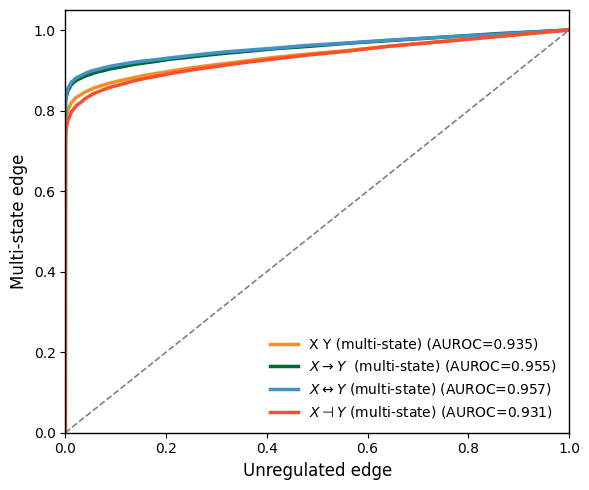

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_multi_state_vs_XY.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_multi_state_vs_XY.png


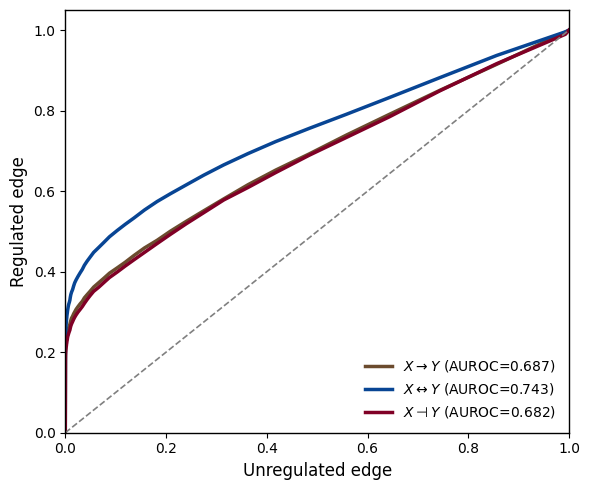

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY.png


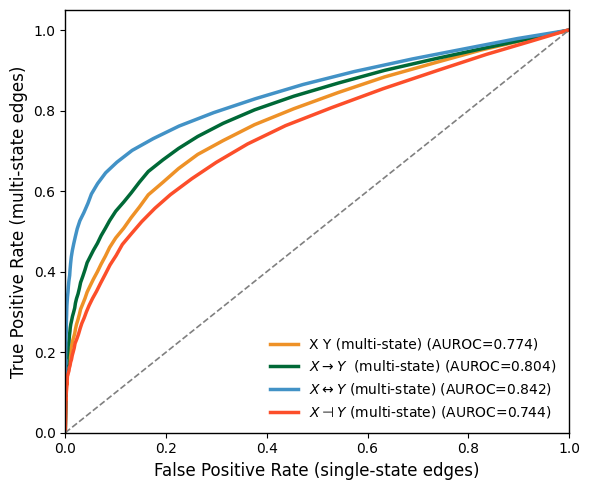

✅ Saved ROC (2-state only): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_multi_only.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_multi_only.png


In [5]:
# === PLOTTING SETTINGS ===
plt.rcParams.update({
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "savefig.transparent": False,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.facecolor": "white",
    "axes.linewidth": 1.0,
    "axes.grid": False
})

fixed_colors = {
    "A_B": "#bc0f58", "A_B_2_states": "#ee9127",
    "A_to_B": "#6b4b2e", "A_to_B_2_states": "#006937",
    "A_and_B": "#084594", "A_and_B_2_states": "#4292c6",
    "A_rep_B": "#800026", "A_rep_B_2_states": "#fc4e2a"
}

# === Plot 1: All vs A_B (Single + Multi-state for regulation detection)
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    if "2_states" not in tp_name:
        continue
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Multi-state edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

# save_all_svg = output_folder_plot / "ROCcurve_multi_state_vs_XY.svg"
# save_all_png = output_folder_plot / "ROCcurve_multi_state_vs_XY.png"
# plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
# plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")

## === Plot 1: All vs A_B (Single + Multi-state for regulation detection)
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    if "2_states" in tp_name:
        continue
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Regulated edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_all_svg = output_folder_plot / "ROCcurve_regulation_vs_XY.svg"
save_all_png = output_folder_plot / "ROCcurve_regulation_vs_XY.png"
# plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
# plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")

# === Plot 2: Only multi-state (2_states vs corresponding single)
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_multi_only:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("False Positive Rate (single-state edges)", fontsize=12)
plt.ylabel("True Positive Rate (multi-state edges)", fontsize=12)
# plt.title("Multi-state identification", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_multi_svg = output_folder_plot / "ROCcurve_multi_only.svg"
save_multi_png = output_folder_plot / "ROCcurve_multi_only.png"
# plt.savefig(save_multi_svg, dpi=600, bbox_inches="tight")
# plt.savefig(save_multi_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (2-state only): {save_multi_svg}, {save_multi_png}")


/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


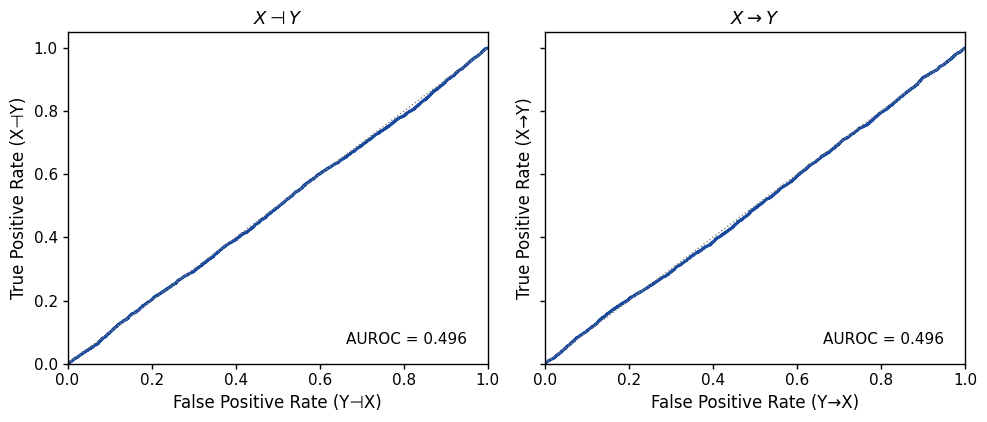


✅ Saved TPR–FPR curves:
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random/TPR_vs_FPR_forward_reverse.png
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random/TPR_vs_FPR_forward_reverse.svg


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc
from pathlib import Path

# === SETTINGS ===
folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan")

pval_global = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20"
zscore_col = "zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1"
pval_A_to_B = "directed_pval_gene_1_mRNA_t1__gene_2_mRNA_t20"
pval_B_to_A = "directed_pval_gene_2_mRNA_t1__gene_1_mRNA_t20"

p_threshold_global = 0.01
z_threshold = 10

name_map = {
    "A_to_B": r"$X \rightarrow Y$",
    "A_rep_B": r"$X \dashv Y$"
}

color_forward = "#194a9e"
color_reverse = "#e84b2c"

files = [f for f in folder.glob("*_inference_results_random_scrambled.csv")
         if any(k in f.stem for k in ["A_to_B", "A_rep_B"]) and ("2_states" not in f.stem)]

fig, axes = plt.subplots(1, len(files), figsize=(10, 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, csv_file in zip(axes, files):
    name = csv_file.stem.replace("_inference_results_random_scrambled", "")
    label_name = name_map.get(name, name)

    df = pd.read_csv(csv_file)
    required = [pval_global, zscore_col, pval_A_to_B, pval_B_to_A]
    if not all(c in df.columns for c in required):
        ax.set_visible(False)
        continue

    # Filter
    df_filt = df[(df[pval_global] < p_threshold_global) & (abs(df[zscore_col]) < z_threshold)]
    if df_filt.empty:
        ax.set_visible(False)
        continue

    # Convert p-values to scores (−log10 p)
    eps = 1e-12
    score_fwd = -np.log10(df_filt[pval_A_to_B].clip(lower=eps))
    score_rev = -np.log10(df_filt[pval_B_to_A].clip(lower=eps))

    # Define labels: forward = True (1), reverse = False (0)
    y_true = np.ones(len(df_filt))

    # Compute ROC-like TPR for forward vs. FPR for reverse
    fpr_fwd, tpr_fwd, _ = roc_curve(y_true, score_fwd)  # both TPR=1 (since all true)
    fpr_rev, tpr_rev, _ = roc_curve(1 - y_true, score_rev)  # both FPR=0 (since all false)

    # Instead, derive matching thresholds
    thresholds = np.sort(np.unique(np.concatenate((score_fwd, score_rev))))
    tpr = [(score_fwd >= t).mean() for t in thresholds]
    fpr = [(score_rev >= t).mean() for t in thresholds]

    # Plot TPR_forward vs FPR_reverse
    ax.plot(fpr, tpr, color=color_forward, lw=2.2)
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
    auroc = auc(fpr, tpr)
    ax.text(
        0.95, 0.05, f"AUROC = {auroc:.3f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11, color="black"
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_title(label_name, fontsize=13)
    # Custom axis labels
    if "A_to_B" in name:
        x_label = "False Positive Rate (Y→X)"
        y_label = "True Positive Rate (X→Y)"
    elif "A_rep_B" in name:
        x_label = "False Positive Rate (Y⊣X)"
        y_label = "True Positive Rate (X⊣Y)"
    else:
        x_label = "False Positive Rate"
        y_label = "True Positive Rate"

    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)


plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# Save
png_path = output_folder_plot / "TPR_vs_FPR_forward_reverse.png"
svg_path = output_folder_plot / "TPR_vs_FPR_forward_reverse.svg"
plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
plt.show()

print(f"\n✅ Saved TPR–FPR curves:\n{png_path}\n{svg_path}")


/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_rep_B_inference_results_random_scrambled.csv
/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_to_B_inference_results.csv
/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_rep_B_inference_results.csv
/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/A_to_B_inference_results_random_scrambled.csv


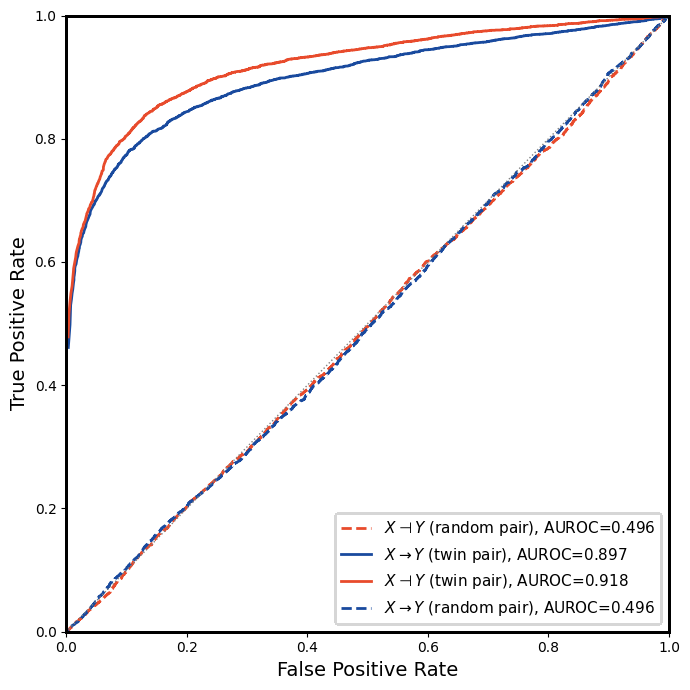

Saved:
/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/combined_TPR_FPR_all4_curves.png
/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/combined_TPR_FPR_all4_curves.svg


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from pathlib import Path

# === SETTINGS ===
folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan")

pval_global = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t20"
zscore_col = "zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1"
pval_A_to_B = "directed_pval_gene_1_mRNA_t1__gene_2_mRNA_t20"
pval_B_to_A = "directed_pval_gene_2_mRNA_t1__gene_1_mRNA_t20"

p_threshold_global = 0.01
z_threshold = 10

# mapping
name_map = {
    "A_to_B": r"$X \rightarrow Y$",
    "A_rep_B": r"$X \dashv Y$"
}

# colors
color_forward = "#194a9e"  # blue
color_reverse = "#e84b2c"  # red

# Find all relevant files
all_files = list(folder.glob("*_inference_results*.csv"))
# Expect four:
#   A_to_B_inference_results.csv
#   A_to_B_inference_results_random_scrambled.csv
#   A_rep_B_inference_results.csv
#   A_rep_B_inference_results_random_scrambled.csv

# --- Helper function to compute FPR–TPR curve ---
def compute_fpr_tpr(df):
    eps = 1e-12
    score_fwd = -np.log10(df[pval_A_to_B].clip(lower=eps))
    score_rev = -np.log10(df[pval_B_to_A].clip(lower=eps))

    thresholds = np.sort(np.unique(np.concatenate((score_fwd, score_rev))))
    tpr = [(score_fwd >= t).mean() for t in thresholds]
    fpr = [(score_rev >= t).mean() for t in thresholds]

    return fpr, tpr, auc(fpr, tpr)


# ------------------------
# PLOT
# ------------------------
fig, ax = plt.subplots(figsize=(7, 7))
import matplotlib as mpl

# 1. NO embedded fonts (Illustrator-friendly)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'   # <-- key for SVG editing

# 2. REMOVE ALL MASKS / ALPHA / CLIPPING
mpl.rcParams['patch.antialiased'] = False
mpl.rcParams['patch.force_edgecolor'] = True
mpl.rcParams['image.composite_image'] = False
mpl.rcParams['axes.linewidth'] = 1.0

for csv_file in all_files:

    stem = csv_file.stem

    if not ("A_to_B" in stem or "A_rep_B" in stem):
        continue
    if ("B_to_A" in stem or "2_states" in stem):
        continue
    if not ("random_scrambled" in stem or "inference_results" in stem):
        continue
    print(csv_file)
    df = pd.read_csv(csv_file)

    # filter
    if not all(c in df.columns for c in [pval_global, zscore_col, pval_A_to_B, pval_B_to_A]):
        continue

    df_filt = df[(df[pval_global] < p_threshold_global) & (abs(df[zscore_col]) < z_threshold)]
    if df_filt.empty:
        continue

    fpr, tpr, auc_val = compute_fpr_tpr(df_filt)

    # determine plotting style
    if "A_to_B" in stem:
        color = color_forward
        label_base = r"$X \rightarrow Y$"
    else:
        color = color_reverse
        label_base = r"$X \dashv Y$"

    if "random_scrambled" in stem:
        linestyle = "--"
        label = label_base + " (random pair)"
    else:
        linestyle = "-"
        label = label_base + " (twin pair)"

    ax.plot(fpr, tpr, lw=2.0, color=color, linestyle=linestyle, label=f"{label}, AUROC={auc_val:.3f}")

# Diagonal
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()

# Save
output = folder / "combined_TPR_FPR_all4_curves"
plt.savefig(str(output) + ".png", dpi=600, bbox_inches="tight")
plt.savefig(str(output) + ".svg", dpi=600, bbox_inches="tight")
plt.show()

print("Saved:")
print(output.with_suffix(".png"))
print(output.with_suffix(".svg"))


## Filter the df based on certain parameters and then plot AUROC

/tmp/ipykernel_2343110/2530105040.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_2343110/2530105040.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_2343110/2530105040.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_2343110/2530105040.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


[Regulation] A_to_B vs A_B: AUROC = 0.751
[Regulation] A_and_B vs A_B: AUROC = 0.771
[Regulation] A_rep_B vs A_B: AUROC = 0.712


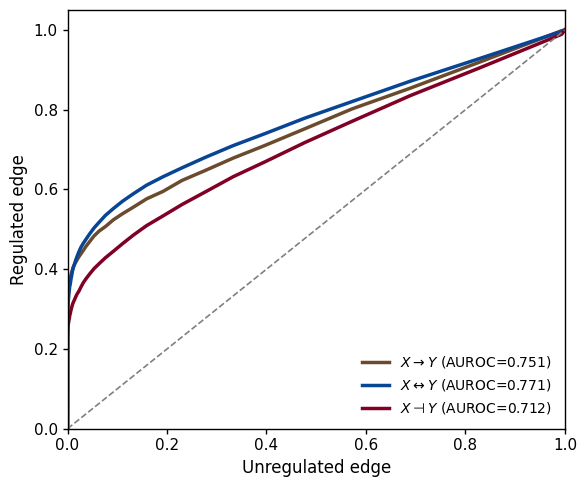

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random/ROCcurve_regulation_vs_XY_k_add_0_4.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random/ROCcurve_regulation_vs_XY_k_add_0_4.png


In [16]:
# === ROC helper ===
def compute_roc(tp_frac, fp_frac):
    fpr = np.clip(fp_frac, 0, 1)
    tpr = np.clip(tp_frac, 0, 1)
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
    if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
    auroc = np.trapz(tpr, fpr)
    return fpr, tpr, auroc

name_map = {
    "A_B": "X Y",
    "A_B_2_states": "X Y (multi-state)",
    "A_to_B": r"$X \rightarrow Y$",
    "A_to_B_2_states": r"$X \rightarrow Y  (multi-state)$",
    "A_and_B": r"$X \leftrightarrow Y$",
    "A_and_B_2_states": r"$X \leftrightarrow Y$ (multi-state)",
    "A_rep_B": r"$X \dashv Y$",
    "A_rep_B_2_states": r"$X \dashv Y$ (multi-state)"
}
# === Generate ROC: PART 1 – Regulation detection (All vs A_B)
dfs = {}
for csv_file in sorted(folder.glob("*_inference_results_random_scrambled.csv")):
    name = csv_file.stem.replace("_inference_results_random_scrambled", "")
    df = pd.read_csv(csv_file)
    if pval_col in df.columns and zscore_col in df.columns and "2_states" not in name:
        dfs[name] = df

# === COMPUTE FRACTIONS ===
frac_curves_p = {}
frac_curves_z = {}

for name, df in dfs.items():
    if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
        df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
    elif "param_index" in df.columns:
        df["_pair_key"] = df["param_index"].astype(str)
    else:
        continue

    # --- For p-value mode (single-state vs XY)

    # --- For z-score mode (multi-state vs single-state)
    if name != "A_B" and "rep" in name:
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 0.8) & (df['gene_id'] == 2)]
    elif name != "A_B":
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 4) & (df['gene_id'] == 2)]
    else:
        df_sig = df[(df['gene_id'] == 2)]
    pair_min_p = df_sig.groupby("_pair_key")[pval_col].min()
    frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])
    if df_sig.empty:
        continue

results_all_vs_A_B = []
for tp_name in ["A_to_B", "A_and_B", "A_rep_B"]:
    fp_name = "A_B"
    if tp_name not in frac_curves_p or fp_name not in frac_curves_p:
        print(f"⚠️ Missing {tp_name} or {fp_name} for regulation ROC")
        continue
    tp_frac = frac_curves_p[tp_name]
    fp_frac = frac_curves_p[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_all_vs_A_B.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Regulation] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")
    
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Regulated edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_all_svg = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_4.svg"
save_all_png = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_4.png"
plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")

/tmp/ipykernel_3842896/3199604945.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_3842896/3199604945.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_3842896/3199604945.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)
/tmp/ipykernel_3842896/3199604945.py:26: DtypeWarning: Columns (0,25,26,27,28,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


[Regulation] A_to_B vs A_B: AUROC = 0.767
[Regulation] A_and_B vs A_B: AUROC = 0.777
[Regulation] A_rep_B vs A_B: AUROC = 0.756


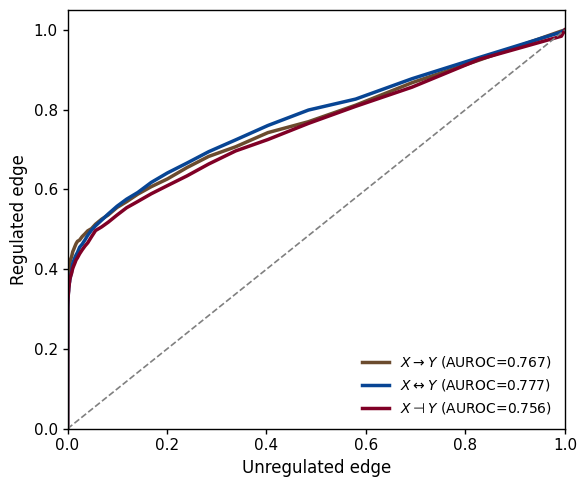

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY_k_add_0_8.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY_k_add_0_8.png


In [63]:
# === ROC helper ===
def compute_roc(tp_frac, fp_frac):
    fpr = np.clip(fp_frac, 0, 1)
    tpr = np.clip(tp_frac, 0, 1)
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
    if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
    auroc = np.trapz(tpr, fpr)
    return fpr, tpr, auroc

name_map = {
    "A_B": "X Y",
    "A_B_2_states": "X Y (multi-state)",
    "A_to_B": r"$X \rightarrow Y$",
    "A_to_B_2_states": r"$X \rightarrow Y  (multi-state)$",
    "A_and_B": r"$X \leftrightarrow Y$",
    "A_and_B_2_states": r"$X \leftrightarrow Y$ (multi-state)",
    "A_rep_B": r"$X \dashv Y$",
    "A_rep_B_2_states": r"X ⊣ Y (multi-state)"
}
# === Generate ROC: PART 1 – Regulation detection (All vs A_B)
dfs = {}
for csv_file in sorted(folder.glob("*_inference_results_random_scrambled.csv")):
    name = csv_file.stem.replace("_inference_results_random_scrambled", "")
    df = pd.read_csv(csv_file)
    if pval_col in df.columns and zscore_col in df.columns and "2_states" not in name:
        dfs[name] = df

# === COMPUTE FRACTIONS ===
frac_curves_p = {}
frac_curves_z = {}

for name, df in dfs.items():
    if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
        df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
    elif "param_index" in df.columns:
        df["_pair_key"] = df["param_index"].astype(str)
    else:
        continue

    # --- For p-value mode (single-state vs XY)

    # --- For z-score mode (multi-state vs single-state)
    if name != "A_B" and "rep" in name:
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 1.6) & (df['gene_id'] == 2)]
    elif name != "A_B":
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 8) & (df['gene_id'] == 2)]
    else:
        df_sig = df[(df['gene_id'] == 2)]
    pair_min_p = df_sig.groupby("_pair_key")[pval_col].min()
    frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])
    if df_sig.empty:
        continue

results_all_vs_A_B = []
for tp_name in ["A_to_B", "A_and_B", "A_rep_B"]:
    fp_name = "A_B"
    if tp_name not in frac_curves_p or fp_name not in frac_curves_p:
        print(f"⚠️ Missing {tp_name} or {fp_name} for regulation ROC")
        continue
    tp_frac = frac_curves_p[tp_name]
    fp_frac = frac_curves_p[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_all_vs_A_B.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Regulation] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")
    
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Regulated edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_all_svg = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_8.svg"
save_all_png = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_8.png"
plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")

## Examples of 2 state systems

In [46]:
from pathlib import Path
parameter_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B")

df_left = pd.read_csv(parameter_folder / "df_row_10128_10129_10130_26082025_142045_ncells_6000_A_B_3fdbd3de.csv")
df_left = df_left[df_left['time_step'] == 1]
df_right = pd.read_csv(parameter_folder / "df_row_71286_71287_27082025_014708_ncells_6000_A_B_22da77f3.csv")
df_right = df_right[df_right['time_step'] == 1]


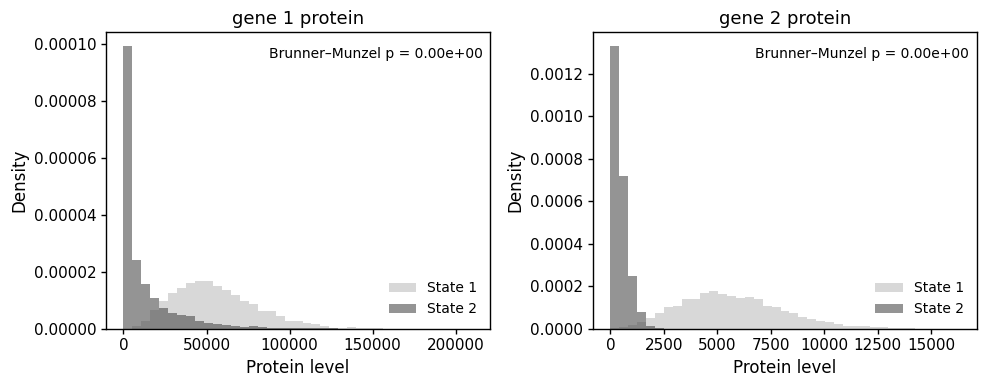

✅ Saved Illustrator-ready histograms:
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/protein_histograms_comparison_1.svg
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/protein_histograms_comparison_1.png


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import brunnermunzel

# === SETTINGS ===
parameter_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B")

# === LOAD DATA ===
df_left = pd.read_csv(parameter_folder / "df_row_10128_10129_10130_26082025_142045_ncells_6000_A_B_3fdbd3de.csv")
df_left = df_left[df_left["time_step"] == 1]

df_right = pd.read_csv(parameter_folder / "df_row_71286_71287_27082025_014708_ncells_6000_A_B_22da77f3.csv")
df_right = df_right[df_right["time_step"] == 1]

# === GENES TO PLOT ===
genes = ["gene_1_protein", "gene_2_protein"]

# === MATPLOTLIB PARAMS (Illustrator-friendly, no transparency or masks) ===
plt.rcParams.update({
    "svg.fonttype": "none",        # keep text editable
    "pdf.fonttype": 42,            # TrueType text (no outlines)
    "savefig.transparent": False,  # remove transparency masks
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False
})

# === FIGURE ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
axes = np.atleast_1d(axes)

# consistent grayscale palette
color_left = "#bfbfbf"   # light gray
color_right = "#4d4d4d"  # dark gray

for ax, gene in zip(axes, genes):
    x_left = df_left[gene].dropna().values
    x_right = df_right[gene].dropna().values

    # use combined range for identical binning
    all_vals = np.concatenate([x_left, x_right])
    bins = np.linspace(all_vals.min(), all_vals.max(), 40)

    # plot histograms (no alpha → no transparency masks)
    ax.hist(x_left, bins=bins, color=color_left, density=True, label="State 1", edgecolor="none", alpha = 0.6)
    ax.hist(x_right, bins=bins, color=color_right, density=True, label="State 2", edgecolor="none", histtype="stepfilled", alpha = 0.6)

    # Brunner–Munzel test
    stat, pval = brunnermunzel(x_left, x_right, nan_policy="omit")

    # annotate
    ax.set_title(gene.replace("_", " "), fontsize=13)
    ax.set_xlabel("Protein level", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.text(0.98, 0.95, f"Brunner–Munzel p = {pval:.2e}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10)

plt.tight_layout()

# === SAVE ===
output_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan")
output_folder.mkdir(exist_ok=True)
svg_path = output_folder / "protein_histograms_comparison_1.svg"
png_path = output_folder / "protein_histograms_comparison_1.png"

plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
plt.show()

print(f"✅ Saved Illustrator-ready histograms:\n{svg_path}\n{png_path}")


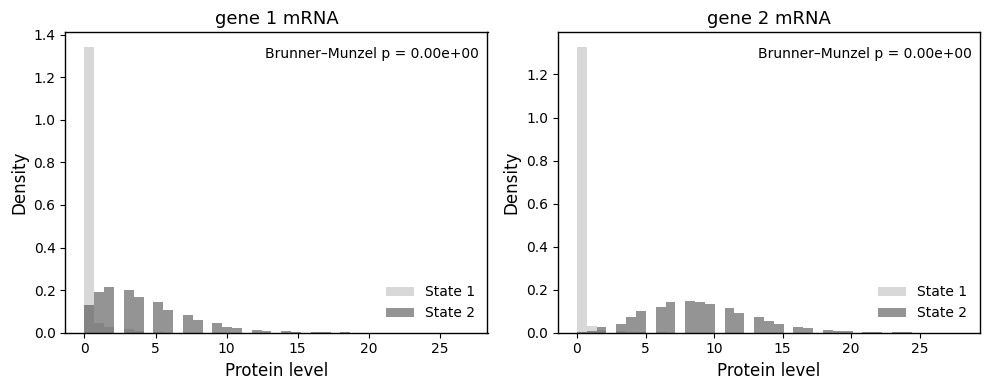

✅ Saved Illustrator-ready histograms:
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random/protein_histograms_comparison_2.svg
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random/protein_histograms_comparison_2.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import brunnermunzel

# === SETTINGS ===
parameter_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B")
path_1 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_6138_6139_6140_26082025_014059_ncells_6000_A_B_6c7dbf5e.csv"
path_2 = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/A_B/df_row_67623_67624_27082025_023623_ncells_6000_A_B_6cb08b28.csv"
# df_row_13110_13111_13112_25082025_121007_ncells_6000_A_B_04b84dc8.csv,df_row_294_295_296_25082025_030916_ncells_6000_A_B_331832f0.csv
# df_row_13110_13111_13112_25082025_121007_ncells_6000_A_B_04b84dc8.csv,df_row_65940_65941_65942_26082025_054621_ncells_6000_A_B_cb604370.csv
# === LOAD DATA ===
# df_left = pd.read_csv(parameter_folder / "df_row_13110_13111_13112_25082025_121007_ncells_6000_A_B_04b84dc8.csv")
# df_left = df_left[df_left["time_step"] == 1]

# df_right = pd.read_csv(parameter_folder / "df_row_294_295_296_25082025_030916_ncells_6000_A_B_331832f0.csv")
# df_right = df_right[df_right["time_step"] == 1]

df_left = pd.read_csv(path_1)
df_left = df_left[df_left["time_step"] == 1]

df_right = pd.read_csv(path_2)
df_right = df_right[df_right["time_step"] == 1]

# === GENES TO PLOT ===
genes = ["gene_1_mRNA", "gene_2_mRNA"]

# === MATPLOTLIB PARAMS (Illustrator-friendly, no transparency or masks) ===
plt.rcParams.update({
    "svg.fonttype": "none",        # keep text editable
    "pdf.fonttype": 42,            # TrueType text (no outlines)
    "savefig.transparent": False,  # remove transparency masks
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False
})

# === FIGURE ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
axes = np.atleast_1d(axes)

# consistent grayscale palette
color_left = "#bfbfbf"   # light gray
color_right = "#4d4d4d"  # dark gray

for ax, gene in zip(axes, genes):
    x_left = df_left[gene].dropna().values
    x_right = df_right[gene].dropna().values

    # use combined range for identical binning
    all_vals = np.concatenate([x_left, x_right])
    bins = np.linspace(all_vals.min(), all_vals.max(), 40)

    # plot histograms (no alpha → no transparency masks)
    ax.hist(x_left, bins=bins, color=color_left, density=True, label="State 1", edgecolor="none", alpha = 0.6)
    ax.hist(x_right, bins=bins, color=color_right, density=True, label="State 2", edgecolor="none", histtype="stepfilled", alpha = 0.6)

    # Brunner–Munzel test
    stat, pval = brunnermunzel(x_left, x_right, nan_policy="omit")

    # annotate
    ax.set_title(gene.replace("_", " "), fontsize=13)
    ax.set_xlabel("Protein level", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.text(0.98, 0.95, f"Brunner–Munzel p = {pval:.2e}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10)

plt.tight_layout()

# === SAVE ===
output_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan_random")
output_folder.mkdir(exist_ok=True)
svg_path = output_folder / "protein_histograms_comparison_2.svg"
png_path = output_folder / "protein_histograms_comparison_2.png"

plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
plt.show()

print(f"✅ Saved Illustrator-ready histograms:\n{svg_path}\n{png_path}")
